# SequenceVis

Converts a CSV matrix of position-specific amino acid frequencies into foreground/background sequence data for visualization.

## Overview

This notebook takes a CSV table of amino acid probabilities at positions -5 to +4 (relative to a motif center) and:
1. **Foreground (fg)**: Converts probabilities into a discrete pool of sequences enriched for the motif
2. **Background (bg)**: Generates random sequences with a constraint at position 0 (only S or T)

## Workflow
1. Configure variables at the top of the notebook
2. Fetch source modules directly from GitHub
3. Provide a CSV input (upload your own or generate random)
4. Convert the CSV into foreground/background datasets
5. Export results as `fg.csv` and `bg.csv`

In [43]:
%%time
# ============================================================
# @title Configuration — Edit these variables to customize your run
# ============================================================

#@markdown ## --- Foreground generation ---
#@markdown ###Number of foreground sequences
FG_SIZE = 1000        #@param {type:"integer"}

#@markdown ## --- Background generation ---
#@markdown ###Number of random background sequences
BG_SIZE = 5000        #@param {type:"integer"}

#@markdown ## --- Random number generation ---
#@markdown ###Seed (for reproducibility) (used when TRUERAND is False)
SEED = 42             #@param {type:"integer"}
#@markdown ###If True, uses a non-deterministic seed; if False, uses SEED
TRUERAND = True       #@param {type:"boolean"}

#@markdown ## --- Output formatting ---
#@markdown ### Decimal places for normalized values
SIGFIGS = 2           #@param {type:"integer"}

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 8.34 µs


## Setup

Install required dependencies and fetch source modules from GitHub.

In [44]:
# Install required packages
!pip install pandas numpy -q

In [45]:
import pandas as pd
import numpy as np
import sys, os, subprocess

## CSV Input

Provide the input CSV file. It will prompt you.

The expected format is a CSV with a `titles` column (amino acid one-letter codes) and numeric columns for each position (-5 to +4).

The input mode is controlled by `GENERATE_RANDOM_INPUT` in the **Configuration** cell above.

In [46]:
import os
from google.colab import files
import pandas as pd # Add this back for pd.read_csv

print('=== CSV Input ===')
print('Please upload your CSV file...')
uploaded = files.upload()

if uploaded:
    original_filename = list(uploaded.keys())[0]
    target_name = 'real_input.csv'

    if os.path.exists(target_name):
        os.remove(target_name)

    os.rename(original_filename, target_name)
    print(f"\nSuccess! '{original_filename}' has been saved as '{target_name}'.")

    try:
        df = pd.read_csv(target_name)
        print(f'Successfully parsed {target_name}.')

        # Identify position columns by attempting to convert them to integers
        position_columns_int = []
        for col in df.columns:
            try:
                # Remove leading '+' for robust integer conversion
                clean_col = str(col).lstrip('+')
                position_columns_int.append(int(clean_col))
            except ValueError:
                # If conversion fails, it's not a position column (e.g., 'Unnamed: 0')
                pass

        if not position_columns_int:
            raise ValueError("No valid integer position columns found in the CSV. Please ensure column headers are integers (e.g., -5, 0, +4).")

        position_columns_int = sorted(position_columns_int)
        global CHAIN_LENGTH
        CHAIN_LENGTH = len(position_columns_int)
        global FIRST_POS
        FIRST_POS = position_columns_int[0]

        print(f"Detected CHAIN_LENGTH from CSV: {CHAIN_LENGTH}")
        print(f"Detected FIRST_POS from CSV: {FIRST_POS}")

    except pd.errors.ParserError as e:
        print(f"Error: Could not parse '{target_name}' as a CSV. Please upload a valid CSV file.")
        print(f"Details: {e}")
        raise
else:
    print('No file uploaded.')
    print('This notebook requires a CSV file to proceed. Please upload one.')
    raise FileNotFoundError("No CSV file uploaded. Please upload a valid CSV file to proceed.")

print(f'\nInput CSV preview for {target_name}:')
print(df.head())

CSV_PATH = f'/content/{target_name}'

=== CSV Input ===
Please upload your CSV file...


Saving input.csv to input.csv

Success! 'input.csv' has been saved as 'real_input.csv'.
Successfully parsed real_input.csv.
Detected CHAIN_LENGTH from CSV: 14
Detected FIRST_POS from CSV: -7

Input CSV preview for real_input.csv:
  titles        -7        -6        -5        -4        -3        -2  \
0      A  0.616966  2.065034  0.373044  1.069080  1.408032  0.666050   
1      C  0.416711  1.317512  0.545112  2.145150  1.931993  0.225817   
2      D  1.747105  0.212682  1.025544  0.767816  1.641157  0.922049   
3      E  2.042154  1.060533  1.765352  0.036003  0.763213  1.745897   
4      F  1.849561  0.998190  1.296774  0.229846  1.583740  0.665819   

         -1         0         1         2         3         4         5  \
0  2.033095  0.242922  1.217150  1.102274  0.957232  1.059154  1.309820   
1  0.196321  0.667783  1.579470  0.848695  0.736632  0.917269  1.652460   
2  0.516821  1.499137  0.312611  1.435668  1.152241  1.703627  0.146180   
3  1.766360  0.583796  0.319048  0.68

## Fetch Source Modules from GitHub

The cells below download the source `.py` files directly from the [sequenceVis GitHub repository](https://github.com/CrankyTitanO7/sequenceVis).

This means the notebook **always stays in sync** with the source code — when the repo is updated, just re-run these cells to get the latest version.

In [47]:
# Fetch biology.py (amino acid alphabet)
# Overwrite if it already exists to prevent errors on multiple runs
if os.path.exists("biology.py"):
    os.remove("biology.py")

!wget -q -O biology.py https://raw.githubusercontent.com/CrankyTitanO7/sequenceVis/main/biology.py
!echo 'biology.py:' && head -3 biology.py

biology.py:
# amino alphabet
AMINO_ALPH = ["A","C","D","E","F","G","H","I","K","L","M","N","P","Q","R","S","T","V","W","Y"]
AMINOS = 20

In [48]:
# Fetch csv-to-fgbg.py (core conversion logic)
# Overwrite if it already exists to prevent errors on multiple runs
if os.path.exists("csv_to_fgbg.py"):
    os.remove("csv_to_fgbg.py")

!wget -q -O csv_to_fgbg.py https://raw.githubusercontent.com/CrankyTitanO7/sequenceVis/main/csv-to-fgbg.py
!echo 'csv_to_fgbg.py:' && wc -l csv_to_fgbg.py

csv_to_fgbg.py:
133 csv_to_fgbg.py


## Import Modules

Import the fetched source modules. The module's import-time tests will run automatically using `real_input.csv`.

In [49]:
# Import the fetched modules
import biology
print('biology loaded:', biology.AMINO_ALPH[:3], '...')

import csv_to_fgbg
print('csv_to_fgbg loaded')
print('  Functions:', [x for x in dir(csv_to_fgbg) if not x.startswith('_')])

biology loaded: ['A', 'C', 'D'] ...
csv_to_fgbg loaded
  Functions: ['AMINOS', 'AMINO_ALPH', 'BG_SIZE', 'CHAIN_LENGTH', 'FG_SIZE', 'PATH', 'SEED', 'SIGFIGS', 'TRUERAND', 'bg', 'bg_dat', 'csv_to_quantity', 'fg', 'fg_dat', 'fg_generate_compiled_sequence', 'fill_blanks', 'norm', 'normalize', 'np', 'open_csv', 'pd', 'rng']


In [50]:
# Apply user configuration to the csv_to_fgbg module
csv_to_fgbg.PATH = CSV_PATH
csv_to_fgbg.FG_SIZE = FG_SIZE
csv_to_fgbg.BG_SIZE = BG_SIZE
csv_to_fgbg.CHAIN_LENGTH = CHAIN_LENGTH # Crucial change here
csv_to_fgbg.SEED = SEED
csv_to_fgbg.TRUERAND = TRUERAND
csv_to_fgbg.SIGFIGS = SIGFIGS

# Recreate the random number generator with the new seed settings
csv_to_fgbg.rng = np.random.default_rng(seed=None if TRUERAND else SEED)

print('Configuration applied:')
print(f'  PATH = {csv_to_fgbg.PATH}')
print(f'  FG_SIZE = {csv_to_fgbg.FG_SIZE}')
print(f'  BG_SIZE = {csv_to_fgbg.BG_SIZE}')
print(f'  CHAIN_LENGTH = {csv_to_fgbg.CHAIN_LENGTH}') # Print the applied value
print(f'  SEED = {csv_to_fgbg.SEED}')
print(f'  TRUERAND = {csv_to_fgbg.TRUERAND}')
print(f'  SIGFIGS = {csv_to_fgbg.SIGFIGS}')

Configuration applied:
  PATH = /content/real_input.csv
  FG_SIZE = 1000
  BG_SIZE = 5000
  CHAIN_LENGTH = 14
  SEED = 42
  TRUERAND = True
  SIGFIGS = 2


## 2. Run the Conversion

Execute the foreground and background generators from the fetched source modules.

All parameters (PATH, FG_SIZE, BG_SIZE, SEED, TRUERAND, SIGFIGS) are configured in the **Configuration** cell at the top of the notebook.

- **Foreground (fg)**: Each position's amino acid probabilities are converted into a discrete pool of 1000 amino acids. Then all 10 positions are compiled into a single sequence string.
- **Background (bg)**: 5000 random 10-mer sequences are generated, with position 0 constrained to only S or T.

Output:
- `fg_full.csv` — full foreground with all columns (sequence + each position)
- `fg.csv` — just the compiled sequence column
- `bg.csv` — background sequences

In [51]:
fg_dat = csv_to_fgbg.fg_generate_compiled_sequence()
print("////////////// foreground generator tests //////////////")
fg_dat.head()

////////////// foreground generator tests //////////////


,sequence,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6
0,ILRHAMECLISWVF,I,L,R,H,A,M,E,C,L,I,S,W,V,F
1,FWMQSHMMMNGAIE,F,W,M,Q,S,H,M,M,M,N,G,A,I,E
2,MGMIHRGSFCHKSI,M,G,M,I,H,R,G,S,F,C,H,K,S,I
3,VVLSCMLNSRDRPH,V,V,L,S,C,M,L,N,S,R,D,R,P,H
4,WGVSADGTPTACKA,W,G,V,S,A,D,G,T,P,T,A,C,K,A


In [52]:
# Create a dynamic background generator tailored to the current CSV
def dynamic_bg(chain_length, first_pos, size, rng):
    bg_seqs = []
    # Dynamically calculate where "0" falls in the array (e.g., abs(-7) = index 7)
    zero_index = abs(first_pos)

    for _ in range(size):
        # Generate a random sequence utilizing the imported biology alphabet
        seq = list(rng.choice(biology.AMINO_ALPH, size=chain_length))

        # Constrain position 0 to only S or T
        seq[zero_index] = rng.choice(['S', 'T'])

        # Compile back into a string
        bg_seqs.append("".join(seq))

    return pd.DataFrame({'bg': bg_seqs})

# Generate background using your globally defined, dynamic variables
bg_dat = dynamic_bg(CHAIN_LENGTH, FIRST_POS, BG_SIZE, csv_to_fgbg.rng)

print("\n////////////// dynamic background generator tests //////////////")
print(bg_dat["bg"].head(10).tolist(), end="... and etc\n")


////////////// dynamic background generator tests //////////////
['HGPWVHNSLPVVWV', 'PADPKMYSCFPNNQ', 'RYEEQTETKSRCNS', 'NSASCYVSPYREED', 'IHEHNRNTLCGLTH', 'SCARPFQTAYHMVL', 'DNVTPFQSEDENPL', 'DQANCIGSGQLRIP', 'YEVFPAASLTSLEF', 'VLGIENRTAWFFHN']... and etc


## 3. Export Results

Save the foreground and background data to CSV files and download them.

In [53]:
bg_dat.to_csv("bg.csv", index=False)
fg_dat.to_csv("fg_full.csv", index=False)
fg_dat.iloc[:, [0]].to_csv("fg.csv", index=False)
print("Exported fg.csv, fg_full.csv, and bg.csv")

Exported fg.csv, fg_full.csv, and bg.csv


In [54]:
from google.colab import files

files.download("fg.csv")
files.download("fg_full.csv")
files.download("bg.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. Visualization with Logomaker

This section installs `logomaker` and creates a sequence logo to visualize the motif found in the foreground dataset compared to the background.

In [55]:
!pip install logomaker -q

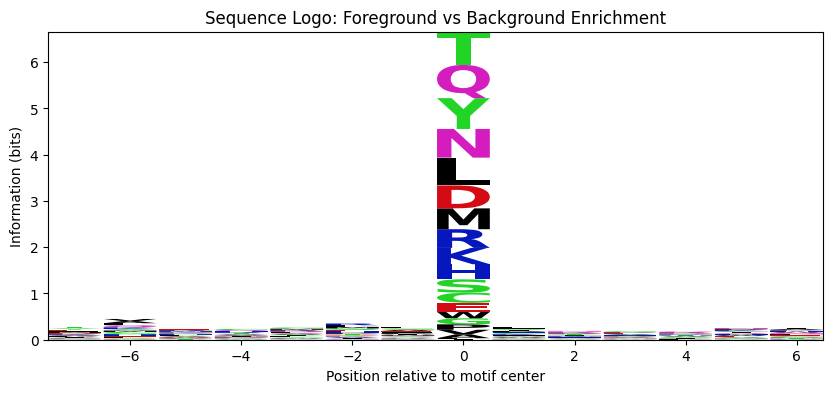

In [56]:
import logomaker
import matplotlib.pyplot as plt

# Helper to convert a list of sequences into a counts matrix
def sequences_to_counts(sequences):
    # Determine length dynamically from the first sequence if available
    if not sequences:
        return pd.DataFrame() # Return empty DataFrame if no sequences

    length = len(sequences[0])
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    counts_df = pd.DataFrame(0, index=range(length), columns=list(amino_acids))

    for seq in sequences:
        for i, char in enumerate(seq):
            if char in counts_df.columns:
                counts_df.loc[i, char] += 1
    return counts_df

# 1. Prepare data
fg_sequences = fg_dat['sequence'].tolist()
bg_sequences = bg_dat['bg'].tolist()

fg_counts = sequences_to_counts(fg_sequences)
bg_counts = sequences_to_counts(bg_sequences)

# 2. Create the Probability matrices
fg_prob = logomaker.transform_matrix(fg_counts, from_type='counts', to_type='probability')
bg_prob = logomaker.transform_matrix(bg_counts, from_type='counts', to_type='probability')

# 3. Calculate Information Content (Enrichment)
# Now fg_prob and bg_prob should have the same number of rows (CHAIN_LENGTH)
# and consistent column names.
logo_df = logomaker.transform_matrix(fg_prob,
                                    from_type='probability',
                                    background=bg_prob,
                                    to_type='information')

# Adjust index to match the actual position numbers from the input CSV
# FIRST_POS and CHAIN_LENGTH should be available globally from csv_input_code
logo_df.index = range(FIRST_POS, FIRST_POS + CHAIN_LENGTH)

# 4. Plot
fig, ax = plt.subplots(figsize=(10, 4))
logo = logomaker.Logo(logo_df, ax=ax, color_scheme='weblogo_protein')

ax.set_ylabel('Information (bits)')
ax.set_xlabel('Position relative to motif center')
ax.set_title('Sequence Logo: Foreground vs Background Enrichment')
plt.show()

## Summary

- **`fg.csv`**: Foreground dataset — one column with compiled 10-mer sequences. Each sequence's amino acids at each position match the input probabilities scaled to 1000 samples.
- **`fg_full.csv`**: Same foreground data but with all position columns (-5 to +4) included for inspection.
- **`bg.csv`**: Background dataset — 5000 random 10-mer sequences with position 0 constrained to S/T.

These files can be used for downstream motif visualization (e.g., sequence logos, position weight matrices, etc.).

---

> **Note**: The source modules (`biology.py`, `csv_to_fgbg.py`, `random_input.py`) are fetched fresh from GitHub each time the setup cells are re-run. This keeps the notebook automatically in sync with the repository.